# ViT-S/16 · 224px 입력에서 `prepare_tokens` 이후 shape

**정답: $(B, 197, 384)$**

- $197 = 1_{\text{CLS}} + 196_{\text{patch}}$, 그리고 $196 = (224/16)^2 = 14^2$
- $384$ = ViT-**S**(small)의 `embed_dim`
- 여기에 위치 임베딩 `pos_embed` $(1, 197, 384)$ 가 **더해진다** (concat 아님 → 토큰 수 불변)

이 스크립트는 손계산 → 실제 DINO 코드 실측 → 내부 단계별 shape 추적 →
해상도/패치 크기별 토큰 수 표 & 시각화 순으로 확인한다.

In [1]:
# 필요 패키지: torch(2.4), plotly(6.9), kaleido, numpy
# DINO 저장소의 실제 vision_transformer.py 를 그대로 import 해서 검증한다.
import os
import sys

import torch

DINO_ROOT = "/home/sungwoo/projects/swcho/dino"
if DINO_ROOT not in sys.path:
    sys.path.insert(0, DINO_ROOT)

import vision_transformer as vits  # noqa: E402

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
torch.manual_seed(0)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 손계산

패치 임베딩은 $16\times16$ 픽셀 블록 하나를 토큰 하나로 만든다. 겹침이 없으므로

$$
N_{\text{patch}} = \left(\frac{H}{P}\right)\left(\frac{W}{P}\right)
  = \left(\frac{224}{16}\right)^2 = 14^2 = 196
$$

여기에 분류/요약용 **CLS 토큰 1개**를 맨 앞에 concat 하므로

$$
N = 196 + 1 = 197
$$

채널 차원은 `vit_small` 의 `embed_dim = 384` 로 고정. 따라서 $(B, 197, 384)$.

In [2]:
IMG, PATCH, EMBED = 224, 16, 384
grid = IMG // PATCH
n_patch = grid * grid
n_token = n_patch + 1
print(f"grid      = {IMG} // {PATCH} = {grid}")
print(f"n_patch   = {grid}^2 = {n_patch}")
print(f"n_token   = {n_patch} + 1(CLS) = {n_token}")
print(f"shape     = (B, {n_token}, {EMBED})")

grid      = 224 // 16 = 14
n_patch   = 14^2 = 196
n_token   = 196 + 1(CLS) = 197
shape     = (B, 197, 384)


## 2. 실측: `vits.vit_small(patch_size=16)`

In [3]:
model = vits.vit_small(patch_size=PATCH)
model.eval()

x = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    tok = model.prepare_tokens(x)

print("input          ", tuple(x.shape))
print("prepare_tokens ", tuple(tok.shape))
assert tuple(tok.shape) == (2, 197, 384)
print("✔ (B, 197, 384) 확인")

input           (2, 3, 224, 224)
prepare_tokens  (2, 197, 384)
✔ (B, 197, 384) 확인


## 3. 파라미터 shape: `cls_token` 과 `pos_embed`

- `cls_token` : $(1, 1, 384)$ — 배치마다 `expand(B, -1, -1)` 로 복제만 한다(메모리 복사 없음)
- `pos_embed` : $(1, 197, 384)$ — **CLS 자리까지 포함**해서 197개다

`prepare_tokens` 는 `x = x + interpolate_pos_encoding(x, w, h)` 로 **덧셈** 브로드캐스트를 한다.
즉 위치 정보는 채널 안에 섞여 들어갈 뿐, 토큰 수나 차원을 늘리지 않는다.

In [4]:
print("cls_token     ", tuple(model.cls_token.shape))
print("pos_embed     ", tuple(model.pos_embed.shape))
print("num_patches   ", model.patch_embed.num_patches)
print("embed_dim     ", model.embed_dim)
print("blocks        ", len(model.blocks), "· heads", model.blocks[0].attn.num_heads)

cls_token      (1, 1, 384)
pos_embed      (1, 197, 384)
num_patches    196
embed_dim      384
blocks         12 · heads 6


## 4. 내부 단계별 shape 추적

`PatchEmbed` 는 사실 **`nn.Conv2d(3, 384, kernel_size=16, stride=16)`** 하나다.
kernel = stride = patch_size 이므로 수용영역이 정확히 한 패치씩, 겹치지 않게 슬라이딩한다.
이는 "패치를 flatten 해서 $\mathbb{R}^{768}\!\to\!\mathbb{R}^{384}$ 선형사영"과 수학적으로 동일하다
($16\times16\times3 = 768$).

$$
(B,3,224,224) \xrightarrow{\text{Conv2d}} (B,384,14,14)
\xrightarrow{\text{flatten(2)}} (B,384,196)
\xrightarrow{\text{transpose(1,2)}} (B,196,384)
$$
$$
\xrightarrow{\text{cat CLS}} (B,197,384) \xrightarrow{+\,\text{pos\_embed}} (B,197,384)
$$

In [5]:
B = 2
with torch.no_grad():
    s0 = x.shape
    c = model.patch_embed.proj(x)          # Conv2d(3, 384, k=16, s=16)
    s1 = c.shape
    f = c.flatten(2)                       # (B, 384, 14*14)
    s2 = f.shape
    t = f.transpose(1, 2)                  # (B, 196, 384)
    s3 = t.shape
    cls = model.cls_token.expand(B, -1, -1)
    s_cls = cls.shape
    cat = torch.cat((cls, t), dim=1)       # (B, 197, 384)
    s4 = cat.shape
    pos = model.interpolate_pos_encoding(cat, 224, 224)
    s_pos = pos.shape
    out = model.pos_drop(cat + pos)
    s5 = out.shape

for name, s in [("0. input            ", s0),
                ("1. Conv2d(k=s=16)   ", s1),
                ("2. flatten(2)       ", s2),
                ("3. transpose(1,2)   ", s3),
                ("   cls_token.expand ", s_cls),
                ("4. cat(CLS, patches)", s4),
                ("   pos_embed(반환)  ", s_pos),
                ("5. + pos_embed      ", s5)]:
    print(name, tuple(s))

print("\nprepare_tokens 결과와 동일? ", torch.allclose(out, tok))

0. input             (2, 3, 224, 224)
1. Conv2d(k=s=16)    (2, 384, 14, 14)
2. flatten(2)        (2, 384, 196)
3. transpose(1,2)    (2, 196, 384)
   cls_token.expand  (2, 1, 384)
4. cat(CLS, patches) (2, 197, 384)
   pos_embed(반환)   (1, 197, 384)
5. + pos_embed       (2, 197, 384)

prepare_tokens 결과와 동일?  True


### CLS 토큰은 정말 0번 위치인가?

`torch.cat((cls_tokens, x), dim=1)` 이므로 인덱스 0이 CLS다.
그래서 `VisionTransformer.forward` 의 마지막이 `return x[:, 0]` — CLS만 뽑아 백본 출력으로 쓴다.

In [6]:
with torch.no_grad():
    feat = model(x)                         # forward: blocks → norm → x[:, 0]
    inter = model.get_intermediate_layers(x, n=1)
    attn = model.get_last_selfattention(x)
print("forward(=CLS)          ", tuple(feat.shape))
print("get_intermediate_layers", tuple(inter[0].shape))
print("get_last_selfattention ", tuple(attn.shape), "  # (B, heads, N, N)")

forward(=CLS)           (2, 384)
get_intermediate_layers (2, 197, 384)
get_last_selfattention  (2, 6, 197, 197)   # (B, heads, N, N)


## 5. 다른 해상도 / patch_size — `interpolate_pos_encoding`

토큰 수는 입력마다 달라진다.

$$
N(H, P) = \left(\frac{H}{P}\right)^2 + 1
$$

`pos_embed` 는 224/16 기준 $14\times14$ 격자로 **학습된 파라미터**라 크기가 고정인데,
`interpolate_pos_encoding` 이 $14\times14$ 격자를 bicubic 업/다운샘플해 맞춰 준다
(CLS 위치 임베딩은 보간에서 제외하고 나중에 다시 concat).
그래서 DINO는 같은 백본으로 224 global crop과 96 local crop을 함께 먹일 수 있다.

In [7]:
rows = []
for img, patch in [(96, 16), (224, 16), (448, 16), (96, 8), (224, 8)]:
    g = img // patch
    rows.append((img, patch, g, g * g, g * g + 1))

print(f"{'img':>5} {'patch':>6} {'grid':>6} {'patches':>8} {'tokens N':>9} {'attn N^2':>10}")
for img, patch, g, np_, nt in rows:
    print(f"{img:5d} {patch:6d} {g:4d}^2 {np_:8d} {nt:9d} {nt*nt:10,d}")

  img  patch   grid  patches  tokens N   attn N^2
   96     16    6^2       36        37      1,369
  224     16   14^2      196       197     38,809
  448     16   28^2      784       785    616,225
   96      8   12^2      144       145     21,025
  224      8   28^2      784       785    616,225


In [8]:
# 같은 모델(224/16으로 pos_embed가 학습된)에 다른 해상도를 넣어도 동작하는지 실측
for size in (96, 224, 448):
    xi = torch.randn(1, 3, size, size)
    with torch.no_grad():
        ti = model.prepare_tokens(xi)
    g = size // PATCH
    print(f"{size:3d}px -> {tuple(ti.shape)}   expected N = {g}^2 + 1 = {g*g+1}")
    assert ti.shape[1] == g * g + 1 and ti.shape[2] == EMBED
print("✔ interpolate_pos_encoding 이 pos_embed 격자를 재조정해 준다")

 96px -> (1, 37, 384)   expected N = 6^2 + 1 = 37
224px -> (1, 197, 384)   expected N = 14^2 + 1 = 197
448px -> (1, 785, 384)   expected N = 28^2 + 1 = 785
✔ interpolate_pos_encoding 이 pos_embed 격자를 재조정해 준다


In [9]:
# patch_size=8 모델은 같은 224 입력에서 토큰이 4배 (28^2 + 1 = 785)
m8 = vits.vit_small(patch_size=8).eval()
with torch.no_grad():
    t8 = m8.prepare_tokens(torch.randn(1, 3, 224, 224))
print("ViT-S/8  pos_embed    ", tuple(m8.pos_embed.shape))
print("ViT-S/8  prepare_tokens", tuple(t8.shape), " # 임베딩 차원 384는 그대로")

ViT-S/8  pos_embed     (1, 785, 384)
ViT-S/8  prepare_tokens (1, 785, 384)  # 임베딩 차원 384는 그대로


## 6. 시각화 — 토큰 수 $N$ 과 어텐션 행렬 크기 $N^2$

어텐션은 토큰 쌍마다 점수를 계산하므로 비용이 $O(N^2)$ 다.
$N \approx (H/P)^2$ 이므로 해상도에 대해 **4제곱**($H^4/P^4$)으로 늘어난다 —
patch 16 → 8 로 줄이면 토큰 4배, 어텐션 16배.

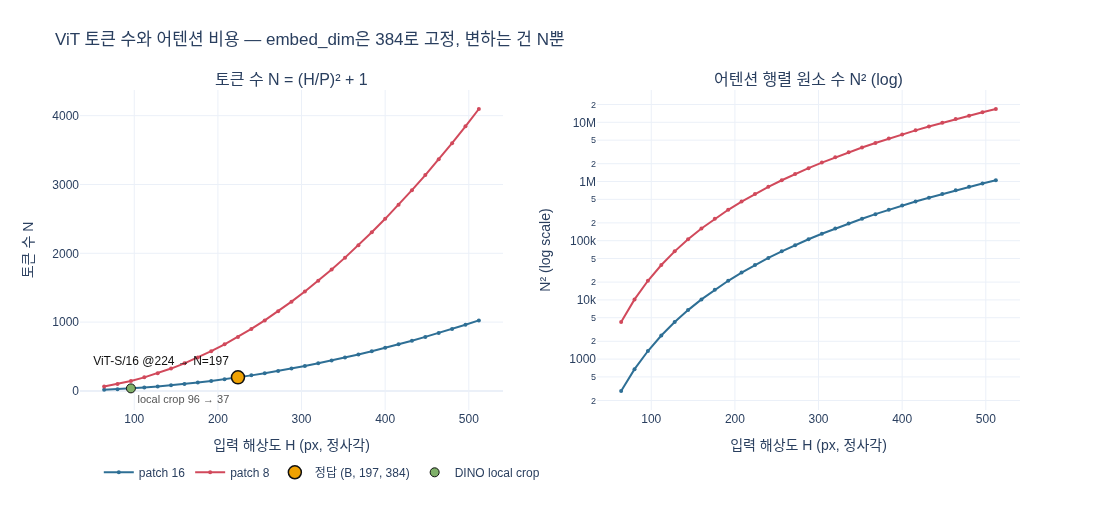

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/c1e545b5-a14a-4618-bfe8-a650ce0f491a/expy.png


In [10]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sizes = np.arange(64, 513, 16)
COLORS = {8: "#d1495b", 16: "#2e6f95"}

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("토큰 수 N = (H/P)² + 1", "어텐션 행렬 원소 수 N² (log)"),
)

for p in (16, 8):
    n = (sizes // p) ** 2 + 1
    fig.add_trace(go.Scatter(x=sizes, y=n, mode="lines+markers",
                             name=f"patch {p}", legendgroup=f"p{p}",
                             line=dict(color=COLORS[p], width=2),
                             marker=dict(size=4)), row=1, col=1)
    fig.add_trace(go.Scatter(x=sizes, y=n.astype(float) ** 2, mode="lines+markers",
                             name=f"patch {p}", legendgroup=f"p{p}", showlegend=False,
                             line=dict(color=COLORS[p], width=2),
                             marker=dict(size=4)), row=1, col=2)

# 정답 지점 (224px, patch 16) → N = 197 강조
fig.add_trace(go.Scatter(x=[224], y=[197], mode="markers+text",
                         text=["ViT-S/16 @224 → N=197"], textposition="top left",
                         textfont=dict(size=12, color="#111"),
                         marker=dict(size=13, color="#f0a202",
                                     line=dict(color="#111", width=1.5)),
                         name="정답 (B, 197, 384)"), row=1, col=1)
# local crop 96px 지점
fig.add_trace(go.Scatter(x=[96], y=[37], mode="markers+text",
                         text=["local crop 96 → 37"], textposition="bottom right",
                         textfont=dict(size=11, color="#555"),
                         marker=dict(size=9, color="#7fb069",
                                     line=dict(color="#111", width=1)),
                         name="DINO local crop"), row=1, col=1)

fig.update_xaxes(title_text="입력 해상도 H (px, 정사각)", row=1, col=1)
fig.update_xaxes(title_text="입력 해상도 H (px, 정사각)", row=1, col=2)
fig.update_yaxes(title_text="토큰 수 N", row=1, col=1)
fig.update_yaxes(title_text="N² (log scale)", type="log", row=1, col=2)
fig.update_layout(
    title="ViT 토큰 수와 어텐션 비용 — embed_dim은 384로 고정, 변하는 건 N뿐",
    template="plotly_white", width=1100, height=520,
    legend=dict(orientation="h", yanchor="bottom", y=-0.24, x=0.02),
    margin=dict(t=90, b=110),
)

_show(fig)
png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

## 정리

| 항목 | 값 | 근거 |
|---|---|---|
| $B$ | 배치 크기 | 그대로 통과 |
| $N$ | $197$ | $(224/16)^2 = 196$ 패치 $+\ 1$ CLS |
| $D$ | $384$ | `vit_small` 의 `embed_dim` (ViT-B는 768, ViT-T는 192) |

헷갈리기 쉬운 지점:

- **위치 임베딩은 더해진다** — `pos_embed` 가 $(1,197,384)$ 라서 197에 뭔가 더 붙는 게 아니다.
- **196이 아니라 197** — CLS 한 자리를 빼먹기 쉽다. `forward` 는 이 0번을 뽑아 리턴한다.
- **384는 해상도와 무관** — 해상도를 바꾸면 $N$ 만 변하고 $D$ 는 아키텍처가 정한다.